# Step 1 - EDA #

I’m doing a first pass through the audio recommendation dataset to get a feel for the songs, their lyrical topic scores, and any patterns that might be useful for unsupervised learning later on. The goal is to understand how the features behave and how they might naturally cluster.

## Context: ##

This project is about building a basic audio recommendation system using an unsupervised learning workflow. The dataset contains songs from 1950–2019 with a mix of metadata (artist, track name, genre, release date) and a set of continuous scores describing how strongly each song’s lyrics relate to different themes (like dating, violence, romantic, familygospel, etc.). There is no explicit target variable to predict, so the focus is on discovering structure in the feature space that could be useful for recommendations.

## Goals: ## 
* Load the training data and understand its shape and basic structure.
* Perform univariate EDA to look at distributions of the main numeric and categorical columns.
* Explore bivariate and multivariate patterns that might hint at natural clusters.
* Start forming hypotheses about which features will matter for clustering and recommendation.

## Import packages ##

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8-talk")
sns.set_palette("deep")

## Load data ##

In [2]:
train_path = "../data/train.csv"
recs_path = "../data/recs.csv"

train = pd.read_csv(train_path)
recs = pd.read_csv(recs_path)

train.head()

,Unnamed: 0,artist_name,track_name,release_date,genre,lyrics,len,dating,violence,world/life,...,communication,obscene,music,movement/places,light/visual perceptions,family/spiritual,sadness,feelings,topic,age
0,0,mukesh,mohabbat bhi jhoothi,1950,pop,hold time feel break feel untrue convince spea...,95,0.000598,0.063746,0.000598,...,0.263751,0.000598,0.039288,0.000598,0.000598,0.000598,0.380299,0.117175,sadness,1.0
1,4,frankie laine,i believe,1950,pop,believe drop rain fall grow believe darkest ni...,51,0.035537,0.096777,0.443435,...,0.001284,0.001284,0.118034,0.001284,0.212681,0.051124,0.001284,0.001284,world/life,1.0
2,6,johnnie ray,cry,1950,pop,sweetheart send letter goodbye secret feel bet...,24,0.002770,0.002770,0.002770,...,0.250668,0.002770,0.323794,0.002770,0.002770,0.002770,0.002770,0.225422,music,1.0
3,10,pérez prado,patricia,1950,pop,kiss lips want stroll charm mambo chacha merin...,54,0.048249,0.001548,0.001548,...,0.001548,0.001548,0.001548,0.129250,0.001548,0.001548,0.225889,0.001548,romantic,1.0
4,12,giorgos papadopoulos,apopse eida oneiro,1950,pop,till darling till matter know till dream live ...,48,0.001350,0.001350,0.417772,...,0.001350,0.001350,0.001350,0.001350,0.001350,0.029755,0.068800,0.001350,romantic,1.0


I’m starting with a quick look at the structure of the dataset. I want to understand the columns, check for missing values, and see what kind of data I’m working with.


In [4]:
train.shape

(28362, 24)

In [5]:
train.dtypes

Unnamed: 0                    int64
artist_name                  object
track_name                   object
release_date                  int64
genre                        object
lyrics                       object
len                           int64
dating                      float64
violence                    float64
world/life                  float64
night/time                  float64
shake the audience          float64
family/gospel               float64
romantic                    float64
communication               float64
obscene                     float64
music                       float64
movement/places             float64
light/visual perceptions    float64
family/spiritual            float64
sadness                     float64
feelings                    float64
topic                        object
age                         float64
dtype: object

In [7]:
train.columns

Index(['Unnamed: 0', 'artist_name', 'track_name', 'release_date', 'genre',
       'lyrics', 'len', 'dating', 'violence', 'world/life', 'night/time',
       'shake the audience', 'family/gospel', 'romantic', 'communication',
       'obscene', 'music', 'movement/places', 'light/visual perceptions',
       'family/spiritual', 'sadness', 'feelings', 'topic', 'age'],
      dtype='object')

From this quick scan, I can see the mix of textual metadata columns (like `artistname`, `trackname`, `genre`, `lyrics`) alongside a set of continuous topic scores and an `age` feature. I’m planning to focus primarily on the numeric topic scores and `age` for clustering, and treat the text-heavy columns as descriptive context rather than features in this first pass.


## Basic data quality checks ##


In [13]:
train.isnull().sum().sort_values(ascending=False)

Unnamed: 0                  0
artist_name                 0
topic                       0
feelings                    0
sadness                     0
family/spiritual            0
light/visual perceptions    0
movement/places             0
music                       0
obscene                     0
communication               0
romantic                    0
family/gospel               0
shake the audience          0
night/time                  0
world/life                  0
violence                    0
dating                      0
len                         0
lyrics                      0
genre                       0
release_date                0
track_name                  0
age                         0
dtype: int64

In [14]:
numeric_cols = train.select_dtypes(include=["float64", "int64"]).columns
train[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,28362.0,42948.166878,24747.811462,0.000000,20393.500000,45407.000000,64089.500000,82451.000000
release_date,28362.0,1990.239652,18.486997,1950.000000,1975.000000,1991.000000,2007.000000,2019.000000
len,28362.0,73.030534,41.831605,1.000000,42.000000,63.000000,93.000000,199.000000
dating,28362.0,0.021110,0.052366,0.000291,0.000923,0.001462,0.004049,0.647706
violence,28362.0,0.118371,0.178658,0.000284,0.001120,0.002506,0.192538,0.981781
world/life,28362.0,0.120984,0.172216,0.000291,0.001170,0.006579,0.197854,0.962105
night/time,28362.0,0.057356,0.111892,0.000289,0.001032,0.001949,0.065778,0.973684
shake the audience,28362.0,0.017418,0.040658,0.000284,0.000993,0.001595,0.009989,0.497463
family/gospel,28362.0,0.017045,0.041968,0.000289,0.000923,0.001504,0.004785,0.545303
romantic,28362.0,0.048676,0.106071,0.000284,0.000975,0.001754,0.042304,0.940789


I want a quick snapshot of the data’s completeness and scale. Here, I’m checking which numeric columns have missing values and how their ranges look. If any topic scores or age are mostly missing or constant, that’s a red flag for later steps.

Looking at the descriptives, a few patterns stand out to me:
* The topic scores are highly skewed toward zero. For many of the lyrical themes (like dating, shake the audience, family/gospel, and family/spiritual), the median is down near the 0.001–0.002 range while the maximum can reach 0.5–0.6 or higher. That tells me most songs barely register on a given theme, but a small subset has very strong signals for that topic.
* Several themes (for example violence, world/life, sadness, and obscene) have higher means and wider spreads than the softer themes. Their standard deviations are relatively large, and the 75th percentile sits much higher, which suggests these topics will have more weight in defining clusters than extremely sparse themes like dating unless I rescale everything carefully.
* The age feature is nicely bounded between 0 and 1 with a mean around 0.43 and a reasonably wide spread (standard deviation around 0.26). That implies songs are distributed across the full historical range rather than being crammed into just the recent or older end of the spectrum, so age has real potential to separate older vs newer clusters.
* The lyrics length (len) varies a lot: the mean is around 73 words with a standard deviation of about 42 and a max just under 200 words. That tells me there’s a mix of short and long songs, but it also warns me that length alone probably shouldn’t dominate clustering; it’s more of a contextual feature than a primary signal.
* The release year centering around 1990 with a wide spread (from 1950 up to 2019) reinforces the idea that the dataset covers multiple eras. I may want to keep release_date or age (but probably not both) when I move into modeling, since they essentially encode the same temporal information on different scales.

Because many topic scores are highly skewed with a few strong signals, I’m planning to standardize these features before clustering so that rarer high-intensity themes do not overwhelm topics that usually sit near zero.

## Univariate EDA: topic scores and age ##

In [11]:
topic_cols = [col for col in numeric_cols if col != "age"]

topic_cols

['Unnamed: 0',
 'release_date',
 'len',
 'dating',
 'violence',
 'world/life',
 'night/time',
 'shake the audience',
 'family/gospel',
 'romantic',
 'communication',
 'obscene',
 'music',
 'movement/places',
 'light/visual perceptions',
 'family/spiritual',
 'sadness',
 'feelings']

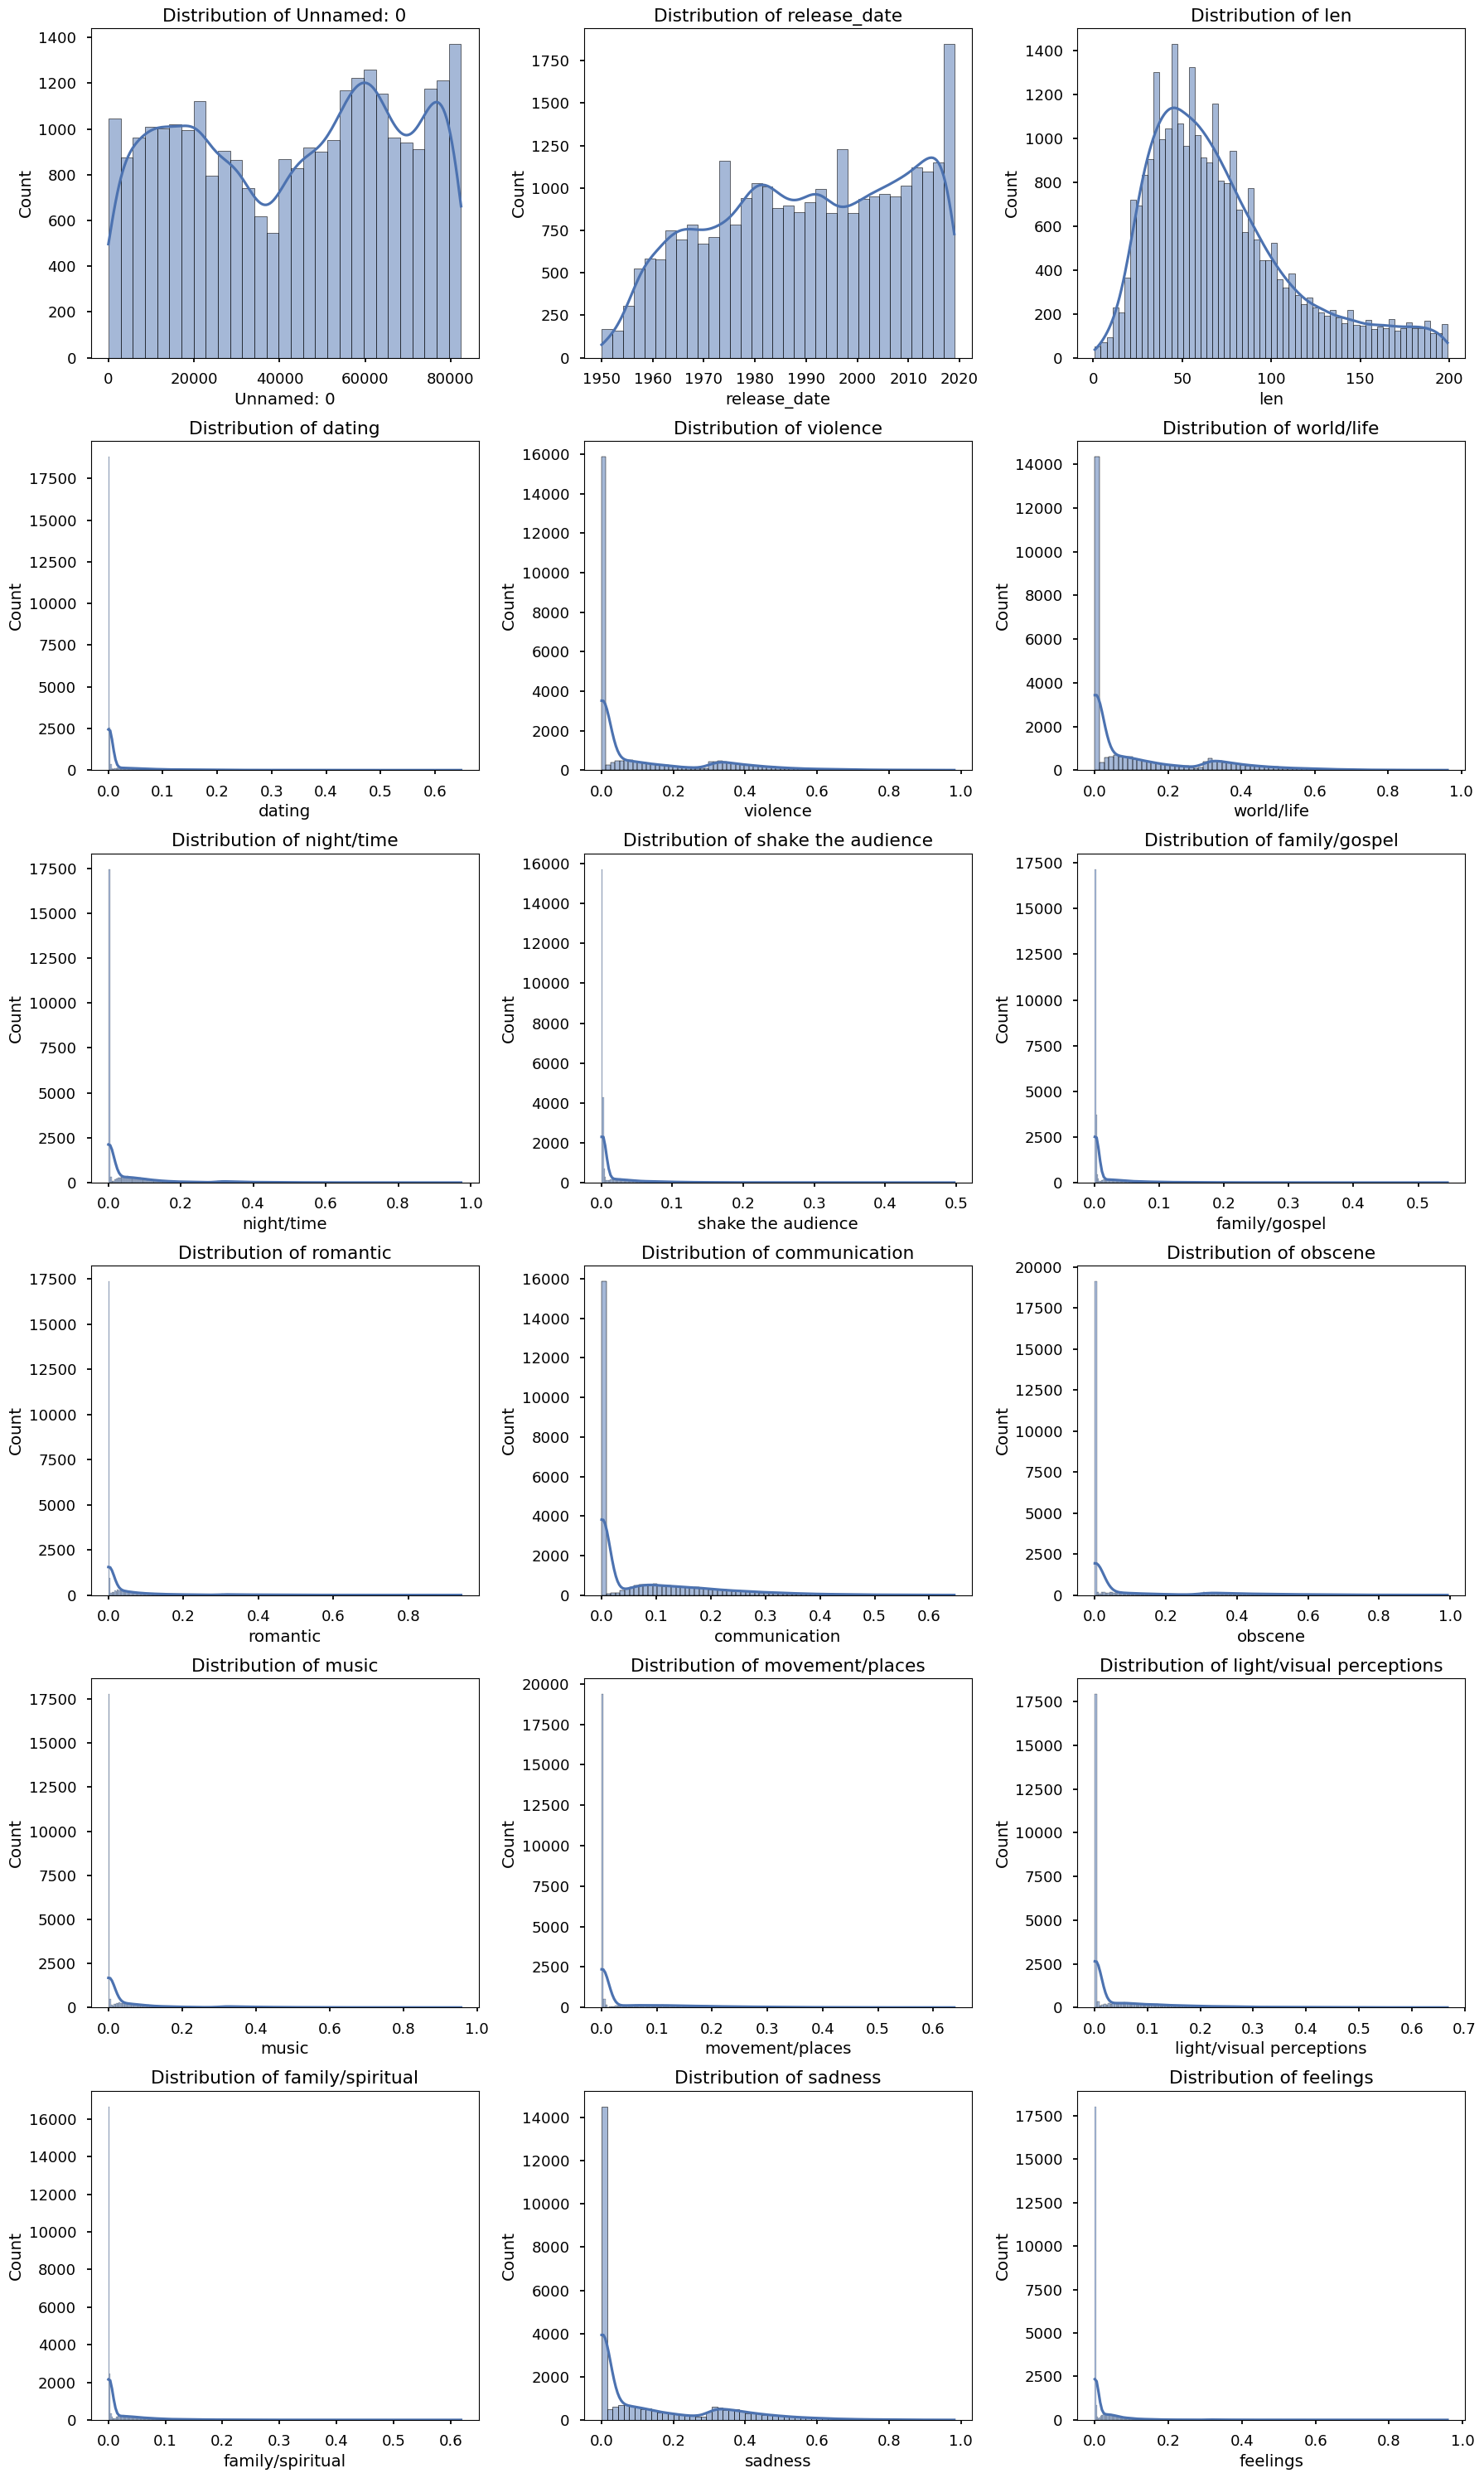

In [12]:
n_cols = 3
n_rows = int(np.ceil(len(topic_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(topic_cols):
    sns.histplot(train[col].dropna(), kde=True, ax=axes[i])
    axes[i].set_title(f"Distribution of {col}")

# Turn off any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

Looking at the histograms, I notice that for almost every topic, the scores are clustered around very low values near zero, with only a smaller group of songs showing higher scores. In other words, most songs barely register on a given theme, and a minority of songs have much stronger values. This tells me that the main differences between songs on a given topic will come from those higher scores, not from tiny variations near zero. That pattern will likely be important to remember for clustering later, because songs with larger topic scores are the ones that will stand out compared with the rest of the dataset.


## Categorical EDA: genre and topic ##

In [15]:
cat_cols = train.select_dtypes(include=["object"]).columns
cat_cols

Index(['artist_name', 'track_name', 'genre', 'lyrics', 'topic'], dtype='object')

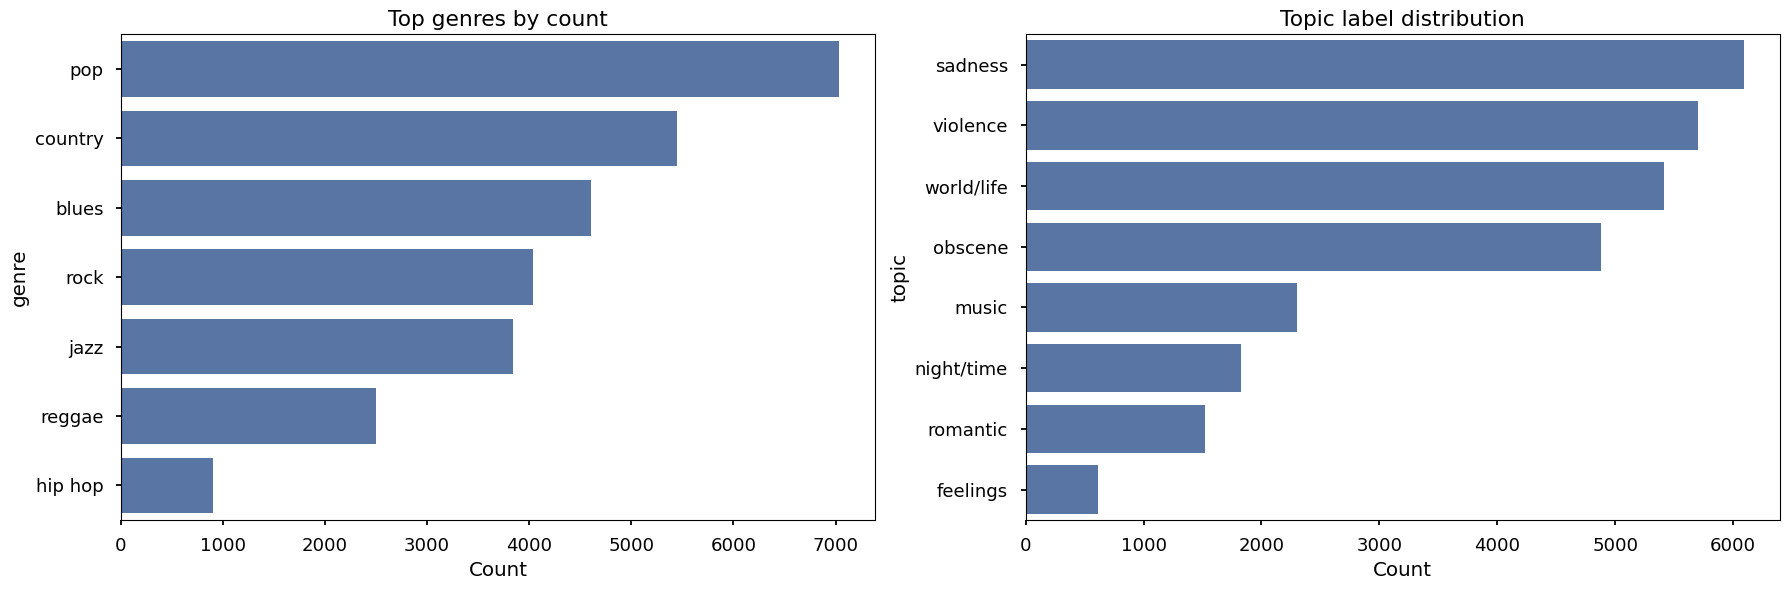

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

if "genre" in train.columns:
    genre_counts = train["genre"].value_counts().head(15)
    sns.barplot(x=genre_counts.values, y=genre_counts.index, ax=axes[0])
    axes[0].set_title("Top genres by count")
    axes[0].set_xlabel("Count")

if "topic" in train.columns:
    topic_counts = train["topic"].value_counts()
    sns.barplot(x=topic_counts.values, y=topic_counts.index, ax=axes[1])
    axes[1].set_title("Topic label distribution")
    axes[1].set_xlabel("Count")

plt.tight_layout()
plt.show()

These barplots give me a quick sense of how the data is distributed across genres and labeled topics. 

On the left, the genre counts are clearly dominated by pop, followed by country, blues, rock, and jazz, with reggae and hip hop making up a smaller share. That means most of my clustering space will be shaped by styles that sit under the broad pop/country/blues/rock umbrella, rather than being evenly balanced across all genres.

On the right, the topic labels are also uneven. Themes like sadness, violence, and world/life appear most often, while topics such as romantic, night/time, and especially feelings are less frequent. This tells me that the dataset leans more heavily toward darker or more serious lyrical themes, at least in terms of the labeled topics, and that some topics will have much more data behind them than others. When I interpret clusters later, I’ll need to remember that both the genre mix and the topic label mix are unbalanced, so some clusters may end up reflecting these dominant categories simply because they are over‑represented in the data.

## Correlation matrix: topics + age ##

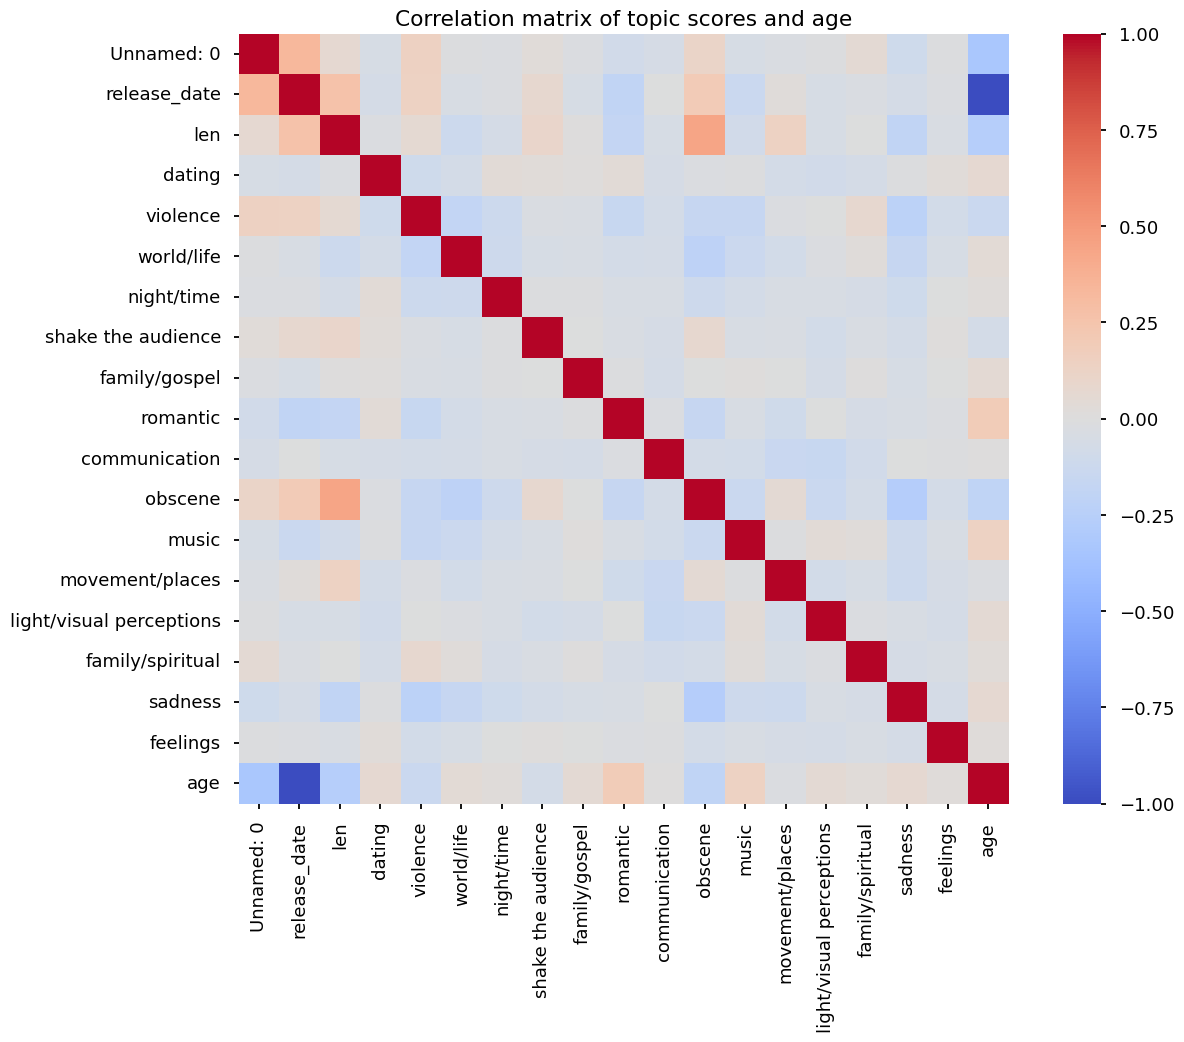

In [17]:
corr = train[topic_cols + ["age"]].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr, cmap="coolwarm", center=0, square=True)
plt.title("Correlation matrix of topic scores and age")
plt.show()

This correlation matrix helps me see how the topic scores, `release_date`, and `age` relate to each other. Most of the off-diagonal entries are fairly light, which tells me that the topics are not highly correlated with one another. In other words, each lyrical theme adds a slightly different piece of information instead of just repeating the same pattern.

One clear pattern is the strong negative relationship between `release_date` and `age`: older songs have higher `age` values and earlier years, while newer songs have lower `age` values and later years. That confirms that these two columns are basically different ways of encoding the same time information, so I probably only need one of them when I build features later. I also see that `len` has a modest positive correlation with `release_date`, suggesting that more recent songs tend to have slightly longer lyrics on average. Overall, there are no obvious pairs of topics that are so tightly linked that I would need to drop one immediately, but this view gives me a mental note that time-related features are closely connected and should be handled carefully in the transformation step.

## Multivariate view (PCA) ##

In [18]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Use topic columns + age as the multivariate feature set
X_topics = train[topic_cols + ["age"]].fillna(0.0)

# Standardize so each feature has mean 0 and std 1
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_topics)

# Reduce to 2 principal components for visualization
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

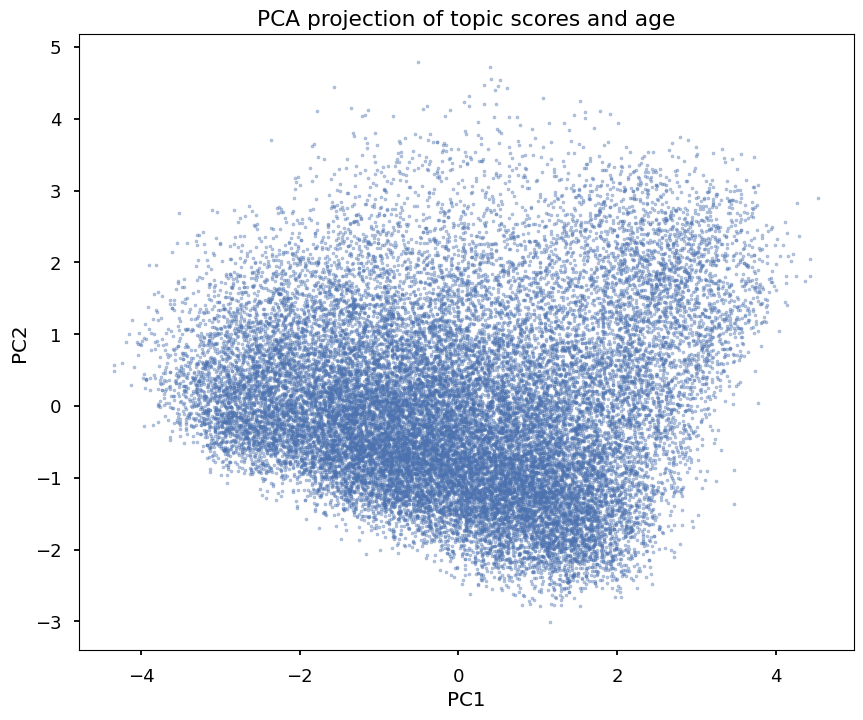

In [19]:
plt.figure(figsize=(10, 8))
plt.scatter(X_pca[:, 0], X_pca[:, 1], s=5, alpha=0.4)
plt.title("PCA projection of topic scores and age")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

This PCA projection is my first multivariate look at the dataset. Each point represents a song, and its coordinates are based on all topic scores plus `age` after standardizing them. The plot shows one main dense cloud with a noticeable spread along the first component (PC1) and a bit less spread along the second component (PC2). There are no clearly separated blobs, just a thick cluster that gradually thins out toward the edges.

To me, this suggests that the songs do not fall into a few perfectly distinct groups in this 2D view. Instead, the structure looks more continuous, with some directions where songs differ more than others. For clustering later on, that means any clusters I find will be about drawing useful boundaries inside a continuous space rather than discovering completely isolated groups. Even so, seeing this variation in the PCA plot reassures me that there is real structure in the data for an algorithm like KMeans to pick up.

## Step 1 summary and working hypotheses ##

So far, this first pass through the data has given me a decent high-level picture. The numeric summaries and histograms showed that most of the topic scores are heavily skewed toward very small values, with only a smaller set of songs taking on higher scores. That means the biggest differences between songs on a given theme will come from those higher values rather than from small variations near zero. The genre and topic barplots also made it clear that the data is not perfectly balanced: pop, country, and blues dominate on the genre side, and themes like sadness, violence, and world/life are the most common labeled topics.

The correlation matrix suggested that most topics are not strongly tied to each other, which is a good sign that each theme contributes its own information instead of simply duplicating another column. One strong pattern I noticed is the negative relationship between `release_date` and `age`, confirming that they encode the same time information in different forms. The PCA view pulled all of this together into a multivariate picture: the songs form one main cloud with gradual variation rather than a few perfectly distinct islands. That tells me there is structure to work with, but the clusters I build later will be about drawing useful boundaries inside a continuous space rather than discovering perfectly separated groups.

Based on this EDA, I have a few working hypotheses to carry into the next steps:
1. Songs that share similar higher topic scores (for example, higher sadness and world/life, or higher obscene and violence) will tend to end up in the same clusters, since those larger values drive most of the differences between songs.
2. Because the dataset is dominated by pop, country, and blues, and by labeled topics such as sadness, violence, and world/life, I expect some clusters to reflect combinations of these genres and themes rather than being evenly spread across all styles and topics.
3. The age feature spans the full range and is strongly related to `release_date`, so it may contribute to clusters that differ partly by era (older versus newer songs), even when their topic profiles are similar.

In the next step, I’ll move from exploration to preparation. I plan to:
1. Drop clearly non-informative or redundant columns like `Unnamed: 0` and choose between `release_date` and `age`
2. Keep the set of topic scores and a single time-related feature as my main inputs
3. Apply minimal cleaning for missing values
4. Standardize these features so that no single column dominates the clustering just because of its scale. 

The goal of Step 2 is to produce a clean, consistent feature matrix that is ready for clustering while staying as close as possible to the patterns I’ve seen in this exploratory analysis.